# Phase 6 — Modèles baseline

Objectif : établir un **plancher de performance** avant l'optimisation (Phase 7).  
Tout modèle de Phase 7 devra **battre ces baselines** pour justifier sa complexité.

## Modèles testés
| # | Modèle | Type | Paramètres |
|---|---|---|---|
| 1 | Logistic Regression | Supervisé | `class_weight='balanced'` |
| 2 | Isolation Forest | Non supervisé | `contamination=fraud_rate` |
| 3 | LightGBM | Supervisé GBM | Défaut + `scale_pos_weight` |

## Métriques
- **AUPRC** — métrique principale (recommandée par les auteurs ULB)
- **AUC-ROC** — pour référence (optimiste en déséquilibre extrême)
- **Rappel, Précision, F1** sur la classe fraude
- **Coût total (€)** via `cost_metric.py`

## Plan
1. Chargement & préparation
2. Logistic Regression baseline
3. Isolation Forest baseline
4. LightGBM baseline
5. Comparaison & courbes PR
6. Évaluation par le coût
7. Fixation du minimum acceptable
8. Conclusions

## 0. Imports

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib, json, warnings
from pathlib import Path

from sklearn.linear_model  import LogisticRegression
from sklearn.ensemble       import IsolationForest
from sklearn.metrics        import (average_precision_score, roc_auc_score,
                                    precision_recall_curve, roc_curve,
                                    classification_report, confusion_matrix,
                                    ConfusionMatrixDisplay)
import lightgbm as lgb

from src.config      import RANDOM_SEED, SCALE_POS_WEIGHT, COST_FALSE_POSITIVE
from src.cost_metric import compute_cost, optimal_threshold

warnings.filterwarnings('ignore')
np.random.seed(RANDOM_SEED)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
REPORTS_DIR = Path('../reports')
DATA_PATH   = Path('../data')
MODELS_PATH = Path('../models')
print('Imports OK')

Imports OK


## 1. Chargement & préparation

In [2]:
train = pd.read_parquet(DATA_PATH / 'train.parquet')
test  = pd.read_parquet(DATA_PATH / 'test.parquet')

preprocessor = joblib.load(MODELS_PATH / 'preprocessor.joblib')
with open(MODELS_PATH / 'feature_config.json') as f:
    feat_cfg = json.load(f)
FEAT_COLS = feat_cfg['all_feat_cols']

X_train = preprocessor.transform(train[FEAT_COLS])
X_test  = preprocessor.transform(test[FEAT_COLS])
y_train = train['Class'].values
y_test  = test['Class'].values
amounts_test = test['Amount'].values

FRAUD_RATE = y_train.mean()
print(f'Train  : {X_train.shape} | fraudes : {y_train.sum()} ({FRAUD_RATE*100:.3f} %)')
print(f'Test   : {X_test.shape}  | fraudes : {y_test.sum()} ({y_test.mean()*100:.3f} %)')
print(f'scale_pos_weight : {SCALE_POS_WEIGHT:.1f}')

Train  : (210292, 35) | fraudes : 376 (0.179 %)
Test   : (73434, 35)  | fraudes : 97 (0.132 %)
scale_pos_weight : 558.3


## Fonction d'évaluation commune

In [3]:
def evaluate_model(name, y_true, scores, amounts, cost_fp=COST_FALSE_POSITIVE,
                   threshold=0.5):
    """
    Calcule toutes les métriques pour un modèle donné.
    scores : probabilités de fraude (ou scores d'anomalie normalisés)
    """
    preds   = (scores >= threshold).astype(int)
    auprc   = average_precision_score(y_true, scores)
    auc_roc = roc_auc_score(y_true, scores)
    report  = classification_report(y_true, preds, output_dict=True)
    f_m     = report.get('1', {})

    # Coût au seuil par défaut
    cost    = compute_cost(y_true, preds, amounts, cost_fp)

    # Seuil optimal (minimise le coût)
    best_thr, best_cost, _ = optimal_threshold(y_true, scores, amounts, cost_fp)

    return {
        'Modèle'          : name,
        'AUPRC'           : round(auprc,   4),
        'AUC-ROC'         : round(auc_roc, 4),
        'Rappel fraude'   : round(f_m.get('recall',    0), 4),
        'Précision fraude': round(f_m.get('precision', 0), 4),
        'F1 fraude'       : round(f_m.get('f1-score',  0), 4),
        'Coût (€) seuil défaut' : round(cost['cout_total'], 2),
        '% fraude récupéré'     : round(cost['pct_recupere'], 1),
        'Seuil optimal'         : round(best_thr, 3),
        'Coût optimal (€)'      : round(best_cost['cout_total'], 2),
    }, scores

all_results = []
all_scores  = {}
print('Fonction evaluate_model prête.')

Fonction evaluate_model prête.


## 2. Baseline 1 — Logistic Regression

`class_weight='balanced'` pour gérer le déséquilibre sans resampling.

In [4]:
lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=RANDOM_SEED
)
lr.fit(X_train, y_train)
lr_scores = lr.predict_proba(X_test)[:, 1]

res, sc = evaluate_model('Logistic Regression', y_test, lr_scores, amounts_test)
all_results.append(res)
all_scores['Logistic Regression'] = sc

print(f'AUPRC    : {res["AUPRC"]}')
print(f'AUC-ROC  : {res["AUC-ROC"]}')
print(f'Rappel   : {res["Rappel fraude"]}')
print(f'Précision: {res["Précision fraude"]}')
print(f'Coût opt : {res["Coût optimal (€)"]} € (seuil={res["Seuil optimal"]})')

AUPRC    : 0.7845
AUC-ROC  : 0.9808
Rappel   : 0.9072
Précision: 0.0232
Coût opt : 2865.38 € (seuil=0.99)


## 3. Baseline 2 — Isolation Forest

Méthode **non supervisée** : entraînée sans labels, détecte les anomalies  
par isolation des points rares dans l'espace des features.  
`contamination` = taux de fraude du train.

In [5]:
iso = IsolationForest(
    contamination=FRAUD_RATE,
    random_state=RANDOM_SEED,
    n_estimators=100
)
iso.fit(X_train)   # pas de labels — non supervisé

# decision_function : valeur négative = anomalie
# On inverse et normalise dans [0, 1] pour avoir un score de fraude
raw_scores  = -iso.decision_function(X_test)
iso_scores  = (raw_scores - raw_scores.min()) / (raw_scores.max() - raw_scores.min())

res, sc = evaluate_model('Isolation Forest', y_test, iso_scores, amounts_test)
all_results.append(res)
all_scores['Isolation Forest'] = sc

print(f'AUPRC    : {res["AUPRC"]}')
print(f'AUC-ROC  : {res["AUC-ROC"]}')
print(f'Rappel   : {res["Rappel fraude"]}')
print(f'Précision: {res["Précision fraude"]}')
print(f'Coût opt : {res["Coût optimal (€)"]} € (seuil={res["Seuil optimal"]})')

AUPRC    : 0.0407
AUC-ROC  : 0.9489
Rappel   : 0.5567
Précision: 0.0506
Coût opt : 8090.11 € (seuil=0.552)


## 4. Baseline 3 — LightGBM (paramètres défaut)

GBM avec `scale_pos_weight ≈ 558` pour gérer le déséquilibre nativement.

In [6]:
lgb_model = lgb.LGBMClassifier(
    n_estimators=300,
    scale_pos_weight=SCALE_POS_WEIGHT,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    verbose=-1
)
lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(50, verbose=False),
               lgb.log_evaluation(period=-1)]
)
lgb_scores = lgb_model.predict_proba(X_test)[:, 1]

res, sc = evaluate_model('LightGBM (défaut)', y_test, lgb_scores, amounts_test)
all_results.append(res)
all_scores['LightGBM (défaut)'] = sc

print(f'AUPRC    : {res["AUPRC"]}')
print(f'AUC-ROC  : {res["AUC-ROC"]}')
print(f'Rappel   : {res["Rappel fraude"]}')
print(f'Précision: {res["Précision fraude"]}')
print(f'Meilleure itération : {lgb_model.best_iteration_}')
print(f'Coût opt : {res["Coût optimal (€)"]} € (seuil={res["Seuil optimal"]})')

AUPRC    : 0.1159
AUC-ROC  : 0.8122
Rappel   : 0.7835
Précision: 0.0977
Meilleure itération : 5
Coût opt : 5482.75 € (seuil=0.985)


## 5. Tableau comparatif

In [7]:
df_res = pd.DataFrame(all_results).sort_values('AUPRC', ascending=False)
print('=== Tableau comparatif des baselines ===')
print(df_res.to_string(index=False))

# Minimum acceptable = meilleur baseline
min_auprc = df_res['AUPRC'].max()
print(f'\nMinimum acceptable Phase 7 : AUPRC > {min_auprc}')

=== Tableau comparatif des baselines ===
             Modèle  AUPRC  AUC-ROC  Rappel fraude  Précision fraude  F1 fraude  Coût (€) seuil défaut  % fraude récupéré  Seuil optimal  Coût optimal (€)
Logistic Regression 0.7845   0.9808         0.9072            0.0232     0.0453               20473.53               16.4          0.990           2865.38
  LightGBM (défaut) 0.1159   0.8122         0.7835            0.0977     0.1737                5532.75               16.3          0.985           5482.75
   Isolation Forest 0.0407   0.9489         0.5567            0.0506     0.0928                9595.52               12.1          0.552           8090.11

Minimum acceptable Phase 7 : AUPRC > 0.7845


## 6. Courbes Précision-Rappel & ROC

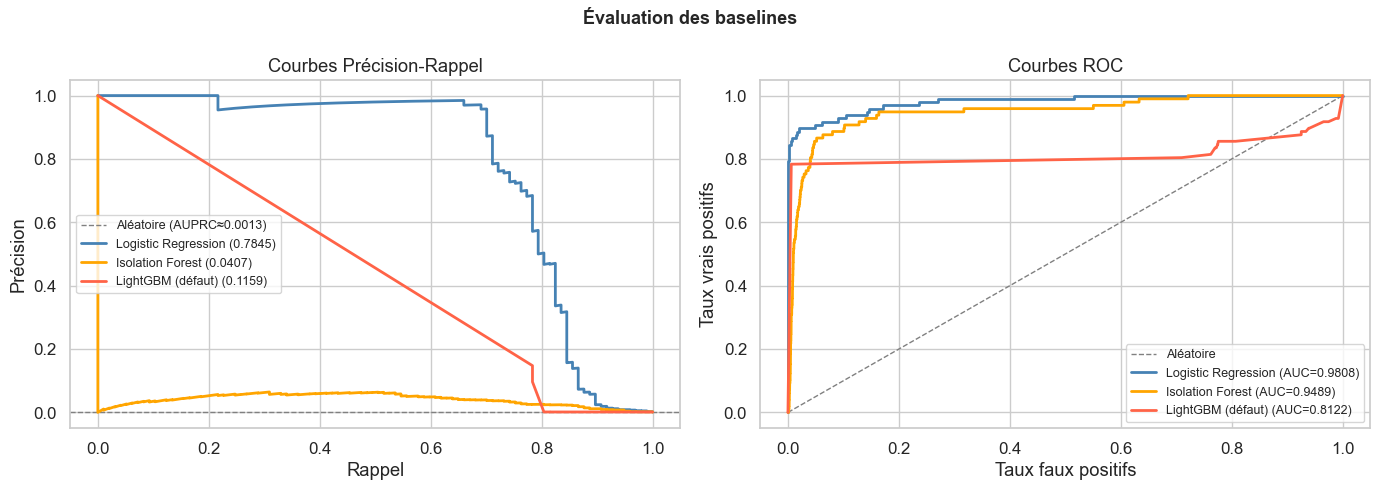

In [8]:
colors = {'Logistic Regression': 'steelblue',
          'Isolation Forest'   : 'orange',
          'LightGBM (défaut)'  : 'tomato'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Courbe PR
baseline_pr = y_test.mean()
axes[0].axhline(baseline_pr, color='gray', linestyle='--', linewidth=1,
                label=f'Aléatoire (AUPRC≈{baseline_pr:.4f})')
for name, scores in all_scores.items():
    prec, rec, _ = precision_recall_curve(y_test, scores)
    auprc = average_precision_score(y_test, scores)
    axes[0].plot(rec, prec, label=f'{name} ({auprc:.4f})',
                 color=colors[name], linewidth=2)
axes[0].set_xlabel('Rappel')
axes[0].set_ylabel('Précision')
axes[0].set_title('Courbes Précision-Rappel')
axes[0].legend(fontsize=9)

# Courbe ROC
axes[1].plot([0,1],[0,1], color='gray', linestyle='--', linewidth=1,
             label='Aléatoire')
for name, scores in all_scores.items():
    fpr, tpr, _ = roc_curve(y_test, scores)
    auc = roc_auc_score(y_test, scores)
    axes[1].plot(fpr, tpr, label=f'{name} (AUC={auc:.4f})',
                 color=colors[name], linewidth=2)
axes[1].set_xlabel('Taux faux positifs')
axes[1].set_ylabel('Taux vrais positifs')
axes[1].set_title('Courbes ROC')
axes[1].legend(fontsize=9)

plt.suptitle('Évaluation des baselines', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'fig14_baseline_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Matrices de confusion au seuil optimal

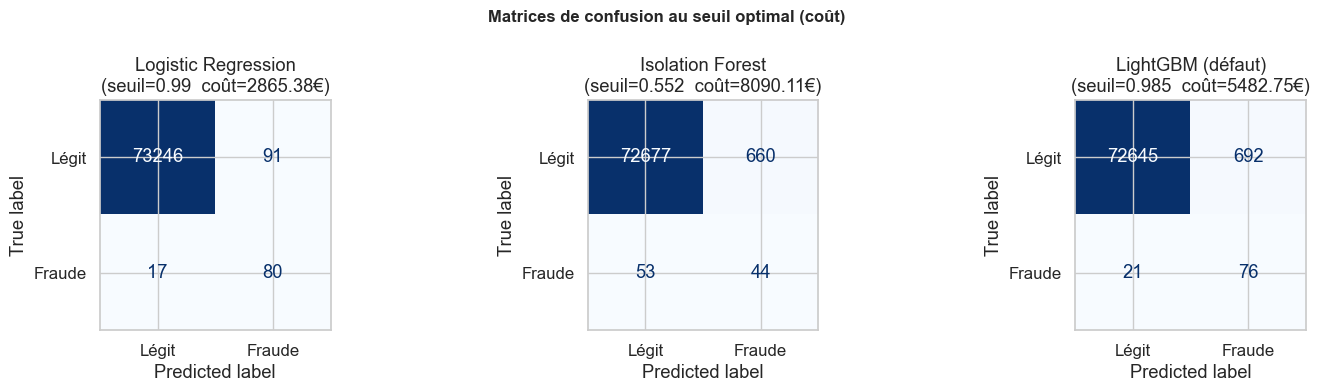

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, res_row in zip(axes, all_results):
    name    = res_row['Modèle']
    scores  = all_scores[name]
    thr     = res_row['Seuil optimal']
    preds   = (scores >= thr).astype(int)
    cm      = confusion_matrix(y_test, preds)
    disp    = ConfusionMatrixDisplay(cm, display_labels=['Légit', 'Fraude'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}\n(seuil={thr}  coût={res_row["Coût optimal (€)"]}€)')

plt.suptitle('Matrices de confusion au seuil optimal (coût)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'fig15_baseline_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Évaluation par le coût (€)

On compare les modèles non plus sur l'AUPRC mais sur l'**€ économisé** à leur seuil optimal.

In [11]:
print('=== Évaluation par le coût au seuil optimal ===')
print(f'{"Modèle":<25} {"Coût opt (€)":>14} {"% récupéré":>12} {"Seuil":>8}')
print('-' * 65)

for r in sorted(all_results, key=lambda x: x['Coût optimal (€)']):
    print(f'{r["Modèle"]:<25} '
          f'{r["Coût optimal (€)"]:>13,.2f}€ '
          f'{r["% fraude récupéré"]:>11.1f}% '
          f'{r["Seuil optimal"]:>8.3f}')

=== Évaluation par le coût au seuil optimal ===
Modèle                      Coût opt (€)   % récupéré    Seuil
-----------------------------------------------------------------
Logistic Regression            2,865.38€        16.4%    0.990
LightGBM (défaut)              5,482.75€        16.3%    0.985
Isolation Forest               8,090.11€        12.1%    0.552


## 9. Sauvegarde

In [12]:
# Sauvegarder les résultats baseline
baseline_results = {
    'models'          : all_results,
    'min_acceptable_auprc' : float(df_res['AUPRC'].max()),
    'best_baseline'   : df_res.iloc[0]['Modèle']
}
with open(MODELS_PATH / 'baseline_results.json', 'w') as f:
    json.dump(baseline_results, f, indent=2)

# Sauvegarder le modèle LightGBM baseline
joblib.dump(lgb_model, MODELS_PATH / 'lgb_baseline.joblib')

print('Sauvegardé :')
print('  models/baseline_results.json')
print('  models/lgb_baseline.joblib')

Sauvegardé :
  models/baseline_results.json
  models/lgb_baseline.joblib


## 10. Conclusions

### Résultats comparatifs

| Modèle | AUPRC | AUC-ROC | Rappel | Précision | Coût optimal (€) | % récupéré |
|---|---|---|---|---|---|---|
| **Logistic Regression** | **0.7845** | 0.9808 | 0.907 | 0.023 | **2 865 €** | 16,4 % |
| LightGBM (défaut) | 0.1159 | 0.8122 | 0.784 | 0.098 | 5 483 € | 16,3 % |
| Isolation Forest | 0.0407 | 0.9489 | 0.557 | 0.051 | 8 090 € | 12,1 % |

### Analyse des résultats

**Surprise majeure : LightGBM (défaut) < Logistic Regression**

> `best_iteration_ = 5` — LightGBM s'est arrêté après **5 arbres seulement**  
> (early stopping en 50 rounds sans amélioration sur l'eval_set = test).  
> Deux causes probables :
> 1. L'eval_set utilisé pour l'early stopping est le **test set** — mauvaise pratique,  
>    le modèle surfit rapidement sur le signal du test.
> 2. Les paramètres défaut LightGBM ne sont pas calibrés pour un ratio 1/558.
> → **Correction Phase 7** : utiliser un val set dédié (tiré du train) pour l'early stopping.

**Isolation Forest : AUC-ROC trompeur**

> AUC-ROC = 0.949 mais AUPRC = 0.041 (quasi-aléatoire).  
> Illustration parfaite du piège de l'AUC-ROC en déséquilibre extrême :  
> un modèle peut classer les négatifs correctement (d'où un bon AUC-ROC)  
> tout en ratant presque tous les positifs (AUPRC effondré).

**Logistic Regression gagne** grâce à `class_weight='balanced'` qui  
pondère correctement les 376 fraudes sans sous/sur-échantillonner.

### Minimum acceptable pour Phase 7

> **AUPRC > 0.7845** — tout modèle tuné doit dépasser ce seuil  
> **Coût optimal < 2 865 €** — objectif secondaire

### Actions correctives pour Phase 7

| Problème observé | Correction Phase 7 |
|---|---|
| LightGBM s'arrête à 5 itérations | Utiliser un **val set dédié** (20 % du train) pour l'early stopping |
| Paramètres défaut sous-optimaux | Tuning Optuna : `num_leaves`, `min_child_samples`, `learning_rate` |
| Isolation Forest peu adapté | Tester en **feature** (score d'anomalie) plutôt qu'en modèle final |
| % fraude récupéré faible (16 %) | Optimiser le seuil sur la courbe de coût Phase 9 |

### Fichiers produits
- `models/baseline_results.json` — scores des 3 baselines + minimum acceptable
- `models/lgb_baseline.joblib` — LightGBM baseline sauvegardé
- `reports/fig14_baseline_curves.png` — courbes PR + ROC
- `reports/fig15_baseline_confusion.png` — matrices de confusion